In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv('dating_app_behavior_dataset_extended1.csv')

# 1. Clean interest_tags: Split them into individual columns (One-Hot Encoding)
df['interest_tags'] = df['interest_tags'].astype(str)
interests_split = df['interest_tags'].str.get_dummies(sep=', ')

# 2. Combine with main data and drop the old column
df = pd.concat([df, interests_split], axis=1)
df = df.drop('interest_tags', axis=1)

print(f"Data loaded. Interests split. Current columns: {df.shape[1]}")

Data loaded. Interests split. Current columns: 73


In [4]:
# DATA CLEANING (Standardizing Text)
# This replaces the weird 'â€™' symbols with a standard apostrophe.
df['education_level'] = df['education_level'].str.replace('’', "'").str.replace('â€™', "'")
for col in ['education_level', 'income_bracket', 'relationship_intent']:
    df[col] = df[col].astype(str).str.replace('’', "'").str.replace('â€™', "'")

print("Text cleaned! 'Masterâ€™s' & 'Bachelorâ€™s' is now 'Master's' and 'Bachelor's, respectively.")

Text cleaned! 'Masterâ€™s' & 'Bachelorâ€™s' is now 'Master's' and 'Bachelor's, respectively.


Gender Distribution Chart: 


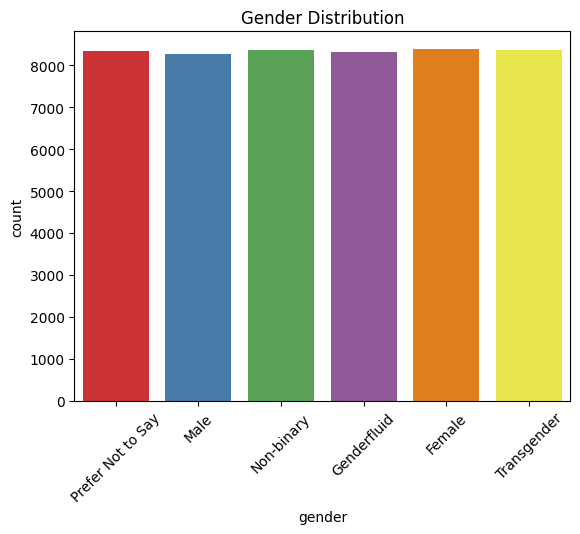

In [5]:
#Gender Distribution Table:
print("Gender Distribution Chart: ")
sns.countplot(data=df, x='gender', hue='gender', palette='Set1')
plt.title("Gender Distribution")
plt.xticks(rotation=45)
plt.show()

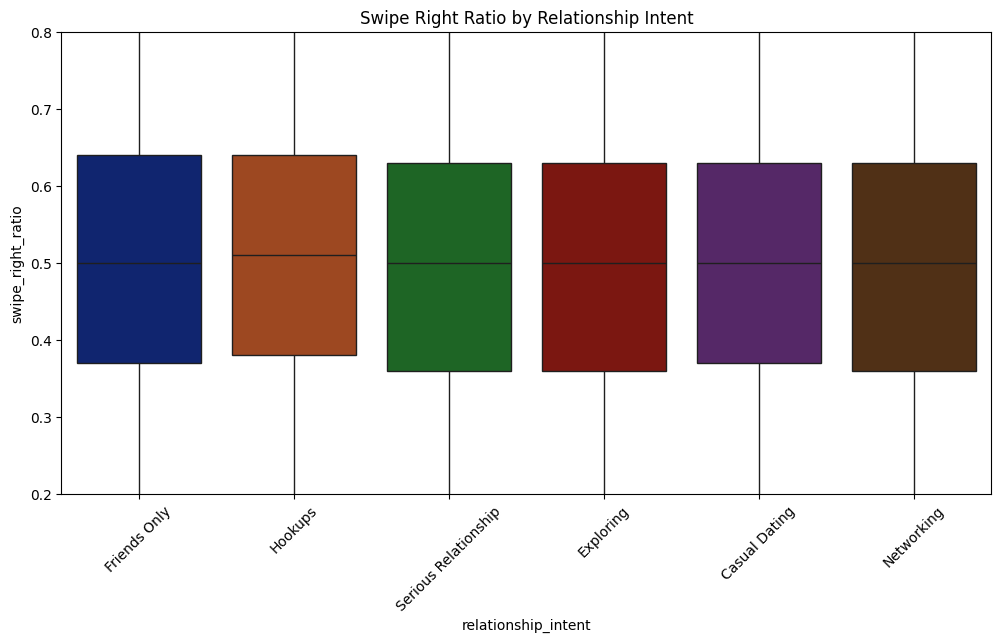

In [6]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='relationship_intent', y='swipe_right_ratio', hue='relationship_intent', palette='dark')
plt.ylim(0.2, 0.8)
plt.title('Swipe Right Ratio by Relationship Intent')
plt.xticks(rotation=45)
plt.show()

In [12]:
# LOGIC: PREDICTING SUCCESS FROM QUALITY
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# DEFINE THE TARGET (y): 1 = Success, 0 = Failure
success_list = ['Relationship Formed', 'Date Happened', 'Mutual Match', 'Instant Match']
df['target_success'] = df['match_outcome'].apply(lambda x: 1 if x in success_list else 0)

# DEFINE THE 3 KEY FEATURES (X): Turning them into 1s and 0s
# Feature 1: Income (1 = High/Mid)
high_income = ['High', 'Very High', 'Upper-Middle', 'Middle']
df['feat_income_high'] = df['income_bracket'].apply(lambda x: 1 if x in high_income else 0)

# Feature 2: Education (1 = Degree and above)
high_edu = ["Bachelor's", "Master's", "PhD", "Postdoc"]
df['feat_edu_high'] = df['education_level'].apply(lambda x: 1 if x in high_edu else 0)

# Feature 3: Intent (1 = Serious/Casual)
high_intent = ['Serious Relationship', 'Casual Dating']
df['feat_intent_high'] = df['relationship_intent'].apply(lambda x: 1 if x in high_intent else 0)

# ENCODE OTHER DATA (Behavioral Quantity)
# We keep these to see if they help the prediction
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    if col not in ['match_outcome', 'relationship_intent', 'income_bracket', 'education_level']:
        df[col] = le.fit_transform(df[col])

# BALANCING THE DATA (50/50 split)
wins = df[df['target_success'] == 1]
losses = df[df['target_success'] == 0]
df_balanced = pd.concat([wins, losses.sample(n=len(wins), random_state=42)])

# FINAL FEATURE SELECTION
# We drop the original text columns and the target column
# The 3 new "feat_" columns we made STAY in X!
drop_cols = ['match_outcome', 'relationship_intent', 'income_bracket',
             'education_level', 'target_success', 'is_high_value']
X = df_balanced.drop(columns=drop_cols, errors='ignore')
y = df_balanced['target_success']

# SPLIT & SCALE(80/20 Train/Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Using Features: High Income, High Education, and Serious/Casual Intent.")
print(f"Predicting Target: Match Success (Win/Loss)")

Using Features: High Income, High Education, and Serious/Casual Intent.
Predicting Target: Match Success (Win/Loss)


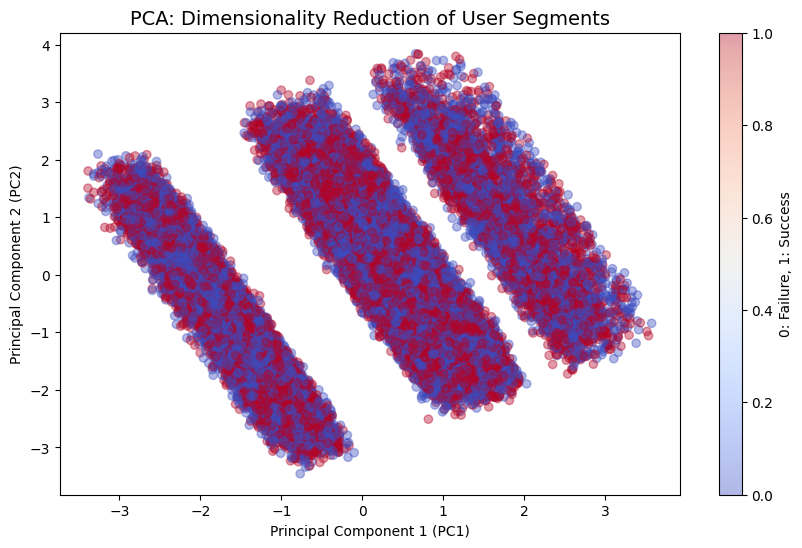

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.4)

plt.title('PCA: Dimensionality Reduction of User Segments', fontsize=14)
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.colorbar(label='0: Failure, 1: Success')
plt.savefig('pca_plot.png')
plt.show()

Logistic Regression done. Accuracy: 50.44%
Decision Tree done. Accuracy: 49.96%
Random Forest done. Accuracy: 50.72%


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVM done. Accuracy: 49.55%
KNN done. Accuracy: 51.11%


/tmp/ipykernel_2406/3216940031.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(results.keys()), y=list(results.values()), palette='magma')


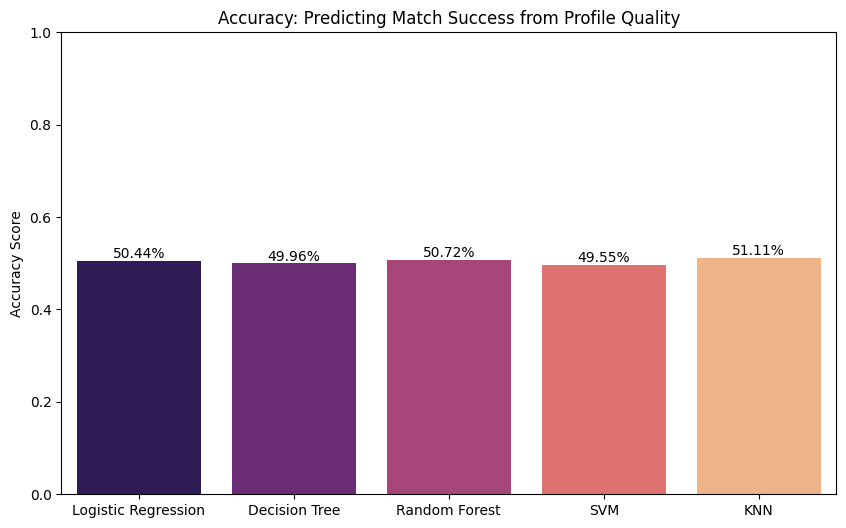

In [14]:
# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(kernel='linear', max_iter=1000),
    "KNN": KNeighborsClassifier()
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    results[name] = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"{name} done. Accuracy: {results[name]:.2%}")

# Plot Bar Chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=list(results.keys()), y=list(results.values()), palette='magma')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.title('Accuracy: Predicting Match Success from Profile Quality')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.0)
plt.show()

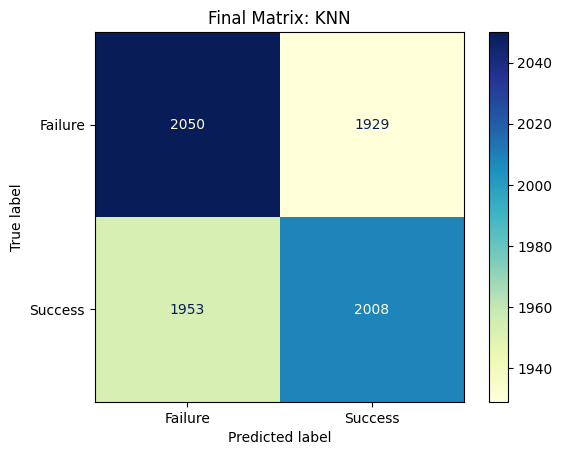

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_name = max(results, key=results.get)
y_pred = models[best_name].predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)


#Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failure', 'Success'])
disp.plot(cmap='YlGnBu')
plt.title(f'Final Matrix: {best_name}')
plt.show()

/tmp/ipykernel_2406/1120100168.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


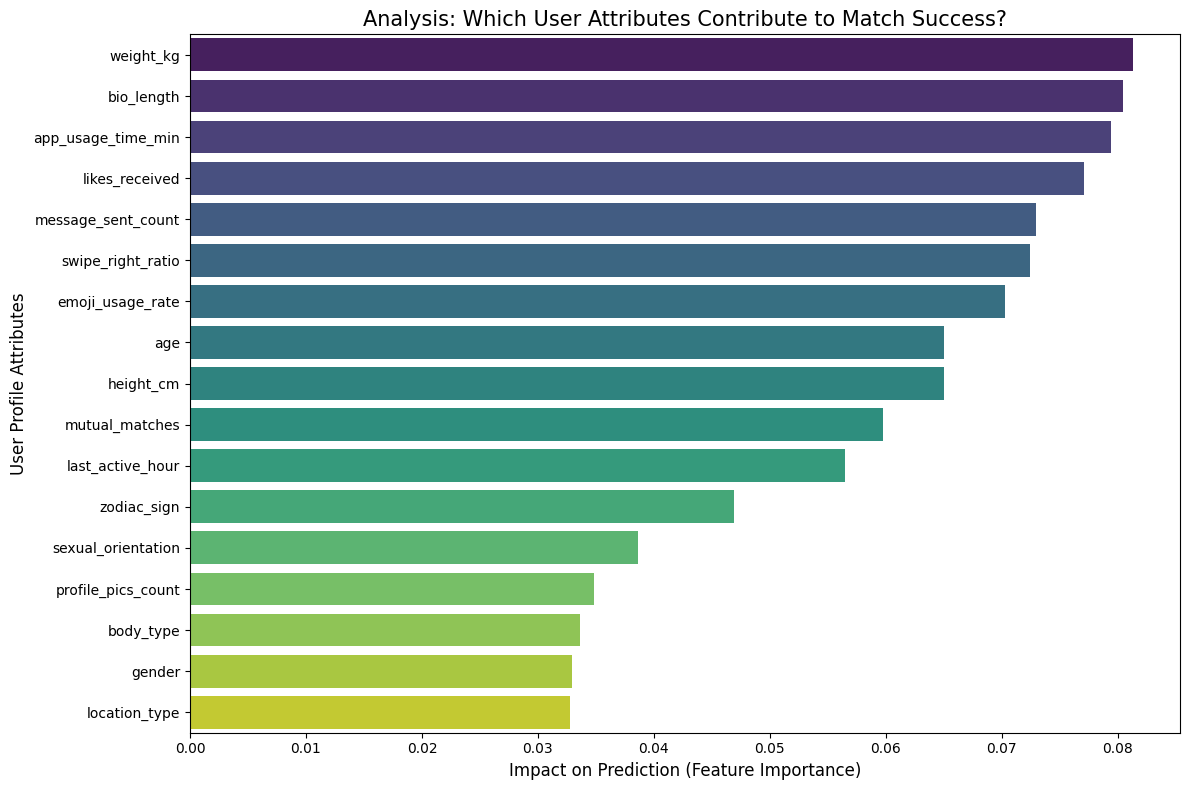

In [23]:
core_categories = [
    'gender', 'sexual_orientation', 'location_type', 'age',
    'height_cm', 'weight_kg', 'body_type', 'zodiac_sign',
    'app_usage_time_min', 'swipe_right_ratio', 'likes_received',
    'mutual_matches', 'message_sent_count', 'profile_pics_count',
    'bio_length', 'emoji_usage_rate', 'last_active_hour'
]

analysis_features = [f for f in core_categories if f in X.columns]
X_analysis = pd.DataFrame(X_train_scaled, columns=X.columns)[analysis_features]

rf_analysis = RandomForestClassifier(n_estimators=100, random_state=42)
rf_analysis.fit(X_analysis, y_train)

importance_df = pd.DataFrame({
    'Feature': analysis_features,
    'Importance': rf_analysis.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 5. Plot the graph
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')

plt.title('Analysis: Which User Attributes Contribute to Match Success?', fontsize=15)
plt.xlabel('Impact on Prediction (Feature Importance)', fontsize=12)
plt.ylabel('User Profile Attributes', fontsize=12)
plt.tight_layout()

# Save this for your report!
plt.savefig('feature_importance_analysis.png')
plt.show()